In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table
from scipy import stats

In [8]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [9]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


## Define a useful cleaning function

In [30]:
# Let's start by making color-redshift plot for redmagic
def remove_outliers(data, bands):
    # All bands are good <3
    catlen = len(data)
    wg = np.full(catlen, True)

    # Pick out only the good entries!
    for band in bands:
        band_mag = np.ma.getdata(data[band])
        band_bool = (band_mag > -9999) & (band_mag != np.nan) & (band_mag < 30)
        wg *= band_bool

    # percent of galaxies that failed
    pfail = 100-(np.count_nonzero(wg) / catlen * 100)

    # How many failed?
    print(f'RedshiftCalc: {np.count_nonzero(wg)}/{catlen} galaxies',
          f'({100-pfail:.1f}%) have good photometry')
    print(f'RedshiftCalc: removing {pfail:.1f}% of galaxies from data')
    print('')

    return wg

In [4]:
catalog_path = '/Users/j.mccleary/Research/dusty_halos/catalogs/prep_cat_output'
hiz = Table.read(os.path.join(catalog_path, 'redmagic_hiz_y3_GOLD_JOINED_catalog.fits'))
hidens = Table.read(os.path.join(catalog_path,'redmagic_hidens_y3_GOLD_JOINED_catalog.fits'))


In [32]:
bands = ['mof_cm_mag_corrected_g', 'mof_cm_mag_corrected_r',
        'mof_cm_mag_corrected_i', 'mof_cm_mag_corrected_z']


wg_hiz = remove_outliers(hiz, bands)
hiz = hiz[wg_hiz]
wg_hidens = remove_outliers(hidens, bands)
hidens = hidens[wg_hidens]

RedshiftCalc: 814318/816199 galaxies (99.8%) have good photometry
RedshiftCalc: removing 0.2% of galaxies from data

RedshiftCalc: 1768477/1772050 galaxies (99.8%) have good photometry
RedshiftCalc: removing 0.2% of galaxies from data



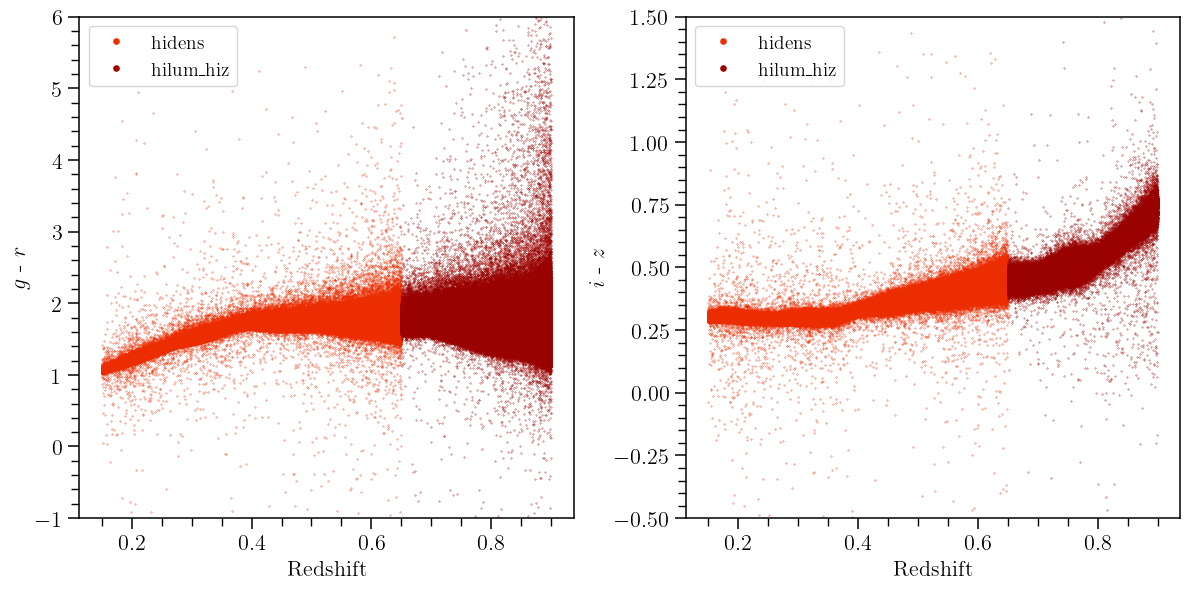

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(12,6), tight_layout=True)
axs[0].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_g'] - hidens['mof_cm_mag_corrected_r']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[0].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_g'] - hiz['mof_cm_mag_corrected_r']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[0].set_ylim(-1,6)
axs[0].legend(markerscale=15, loc='upper left')
axs[0].set_xlabel('Redshift')
axs[0].set_ylabel(r'$g$ - $r$')

axs[1].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_i'] - hidens['mof_cm_mag_corrected_z']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[1].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_i'] - hiz['mof_cm_mag_corrected_z']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[1].set_ylim(-0.5,1.5)
axs[1].legend(markerscale=15, loc='upper left')
axs[1].set_xlabel('Redshift')
axs[1].set_ylabel(r'$i$ - $z$')

fig.savefig('color_redshift_redmagic.pdf')
fig.savefig('color_redshift_redmagic.png')

## OK, let's try Av histogram

In [5]:
catdir = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/'
hiz_tcatname = 'redmagic_hiz/dust_correlation_calzetti00_treecorrcat.fits'
hiz_tcatname2 = 'redmagic_hiz/dust_correlation_calzetti00_4zbins_treecorrcat.fits'

hiz_tcat = Table.read(os.path.join(catdir, hiz_tcatname))
hiz_tcat2 = Table.read(os.path.join(catdir, hiz_tcatname2))

hidens_tcatname = 'redmagic_hidens/dust_correlation_calzetti00_treecorrcat.fits'
hidens_tcatname2 = 'redmagic_hidens/dust_correlation_calzetti00_8zbins_treecorrcat.fits'

hidens_tcat = Table.read(os.path.join(catdir, hidens_tcatname))
hidens_tcat2 = Table.read(os.path.join(catdir, hidens_tcatname2))


In [6]:
hiz_tcat.info()

<Table length=814104>
name  dtype 
---- -------
  ra float64
 dec float64
   w float64
   k float64


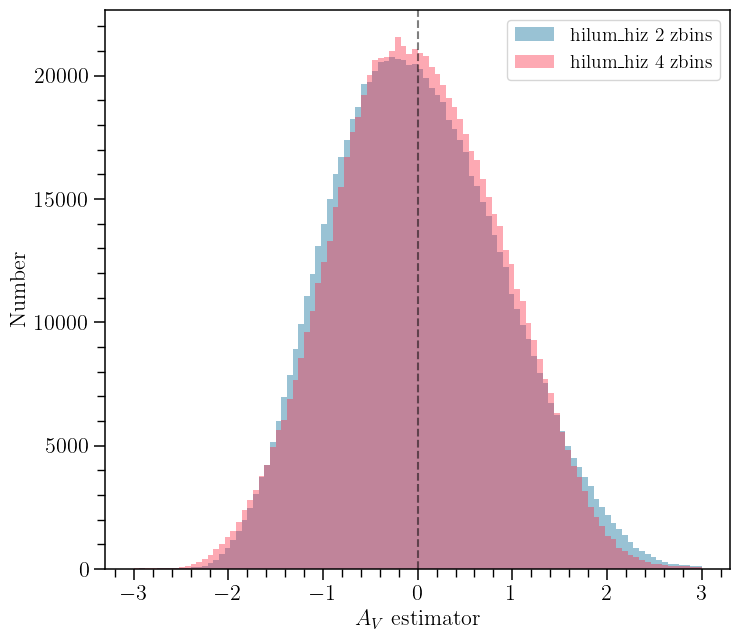

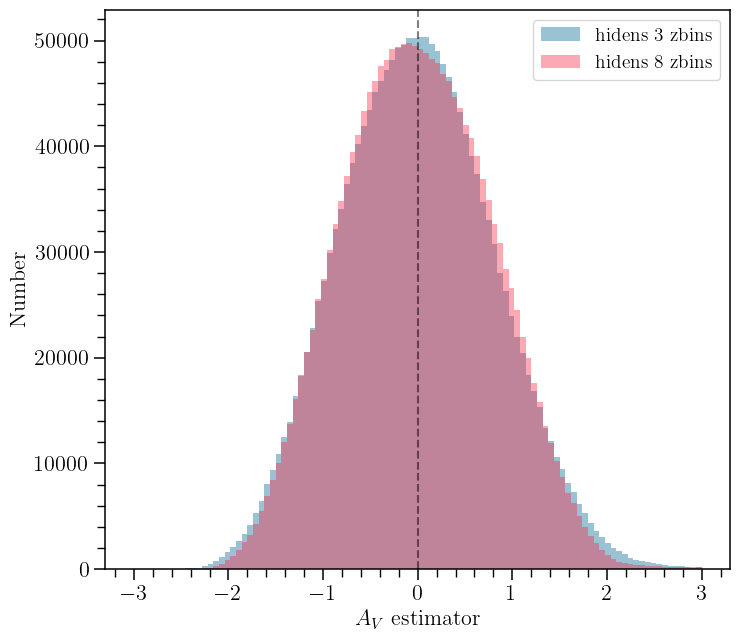

In [15]:
plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hiz_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hilum_hiz 2 zbins', alpha=0.4, color='xkcd:peacock blue')
plt.hist(hiz_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hilum_hiz 4 zbins', color='xkcd:strawberry', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.savefig('hilum_hiz_Av_hist.pdf')
plt.savefig('hilum_hiz_Av_hist.png')

###
### Now repeat for hidens
###

plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hidens_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hidens 3 zbins', alpha=0.4, color='xkcd:peacock blue')
plt.hist(hidens_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hidens 8 zbins', color='xkcd:strawberry', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.savefig('hidens_Av_hist.pdf')
plt.savefig('hidens_Av_hist.png')


In [22]:
hz_wg = np.abs(hiz_tcat['k'])<10
hz_wg2 = np.abs(hiz_tcat2['k'])<10

hiz_stats = stats.describe(hiz_tcat[hz_wg]['k'])
hiz_stats2 = stats.describe(hiz_tcat2[hz_wg2]['k'])

print('hilum_hiz 2 z bins statistics:')
print(f'{hiz_stats}')
print(f"median: {np.median(hiz_tcat[hz_wg]['k'])}")

print('')
print('hilum_hiz 4 z bins statistics:')
print(f'{hiz_stats2}')
print(f"median: {np.median(hiz_tcat2[hz_wg]['k'])}")


### For hidens, now
hd_wg = np.abs(hidens_tcat['k'])<10
hd_wg2 = np.abs(hidens_tcat2['k'])<10

hidens_stats = stats.describe(hidens_tcat[hd_wg]['k'])
hidens_stats2 = stats.describe(hidens_tcat2[hd_wg2]['k'])

print('')
print('hidens 3 z bins statistics:')
print(hidens_stats)
print(f"median: {np.median(hidens_tcat[hd_wg]['k'])}")

print('')
print('hidens 8 z bins statistics:')
print(hidens_stats2)
print(f"median: {np.median(hidens_tcat2[hd_wg2]['k'])}")


hilum_hiz 2 z bins statistics:
DescribeResult(nobs=813766, minmax=(-9.999186492261739, 9.841495528555482), mean=0.005503899939534612, variance=0.8414327482659033, skewness=0.20781776350157782, kurtosis=2.5934334660283467)
median: -0.045604544683410374

hilum_hiz 4 z bins statistics:
DescribeResult(nobs=813695, minmax=(-9.980396161897977, 9.93417580395202), mean=0.00646300642819034, variance=0.7934060135833334, skewness=-0.02135817986077601, kurtosis=2.5756721650504764)
median: -0.017557653876762072

hidens 3 z bins statistics:
DescribeResult(nobs=1767894, minmax=(-9.998180975149177, 9.996185372327092), mean=0.0015200176973255758, variance=0.7077319125997181, skewness=0.3102735277967731, kurtosis=3.7214575389375915)
median: -0.016844864359603653

hidens 8 z bins statistics:
DescribeResult(nobs=1767850, minmax=(-9.99238090824963, 9.983101836175123), mean=0.002770831368295532, variance=0.6588610966225764, skewness=0.23893434430163119, kurtosis=4.068852866372267)
median: -0.015270431654351

In [113]:
hidens_stats2.skewness

-0.15912700926514664